# SMS Spam: базовый пайплайн работы с текстами

**Датасет:** SMS Spam Collection (`spam` / `ham`)  
**Цель:** пройти путь от сырого текста до наивного Байеса и метрик качества.

Работа по пунктам задания: загрузка → токенизация → очистка → Count/TF-IDF → Naive Bayes → выводы.


In [1]:
# Импорты
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Ресурсы NLTK для токенизации, стоп-слов и лемм
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)


## 1. Загрузка и первичный анализ

Для классификации текстов нужны два столбца: сам **текст** и **метка класса**.  
Сначала смотрим размер, баланс классов и «шум» в сообщениях (сокращения, ссылки, странные символы).

**На нашем примере.**  
SMS Spam Collection: сообщения телефонов с метками `ham` (обычное) и `spam` (реклама/обман).


In [2]:
# Путь к уже скачанному файлу
DATA_PATH = "smsspamcollection/SMSSpamCollection"

# Читаем TSV: колонка метки и колонка текста
df = pd.read_table(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "sms_message"],
)

print("Размер датасета:", df.shape)
print("Колонки:", list(df.columns))
print("\nРаспределение классов:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))


Размер датасета: (5572, 2)
Колонки: ['label', 'sms_message']

Распределение классов:
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     0.866
spam    0.134
Name: proportion, dtype: float64


In [3]:
# Примеры текстов с метками
display(df.head(10))


,label,sms_message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


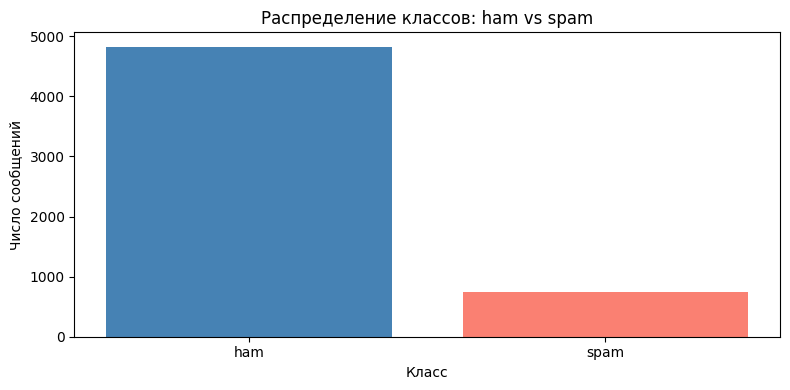

In [4]:
# Столбчатая диаграмма баланса классов
counts = df["label"].value_counts()
fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color=["steelblue", "salmon"])
ax.set_title("Распределение классов: ham vs spam")
ax.set_xlabel("Класс")
ax.set_ylabel("Число сообщений")
plt.tight_layout()
plt.show()


### Вывод по пункту 1

1. Классы **несбалансированы**: ham ≈ **86.6%**, spam ≈ **13.4%** (4825 vs 747).  
2. В текстах много сокращений (`u`, `wif`, `lar`), точек, цифр и кодов — всё это шум для модели.  
3. Из-за дисбаланса нельзя опираться только на accuracy: важно смотреть Precision/Recall/F1 по спаму.


## 2. Токенизация и базовая статистика

- **Токен** — кусочек текста после нарезки (обычно слово или знак).  
- **Тип** — уникальный токен в предложении (повторы не считаем).  
- **Лексема (лемма)** — словарная форма слова: `going` → `go`, `messages` → `message`.

**На нашем примере.**  
Берём 5 SMS и считаем токены / типы / леммы до полной очистки корпуса.


In [5]:
# Берём 5 разных сообщений из датасета
sample_texts = df["sms_message"].iloc[[0, 2, 5, 8, 15]].tolist()

lemmatizer = WordNetLemmatizer()  # инструмент для лемм английских слов
rows = []

for i, text in enumerate(sample_texts, start=1):
    tokens = word_tokenize(text.lower())  # токенизация + нижний регистр
    types = set(tokens)  # уникальные токены
    # Леммы только для «словесных» токенов из букв
    lemmas = {lemmatizer.lemmatize(t) for t in tokens if t.isalpha()}
    rows.append({
        "id": i,
        "text_short": text[:60] + ("..." if len(text) > 60 else ""),
        "n_tokens": len(tokens),
        "n_types": len(types),
        "n_lemmas": len(lemmas),
    })

stats_table = pd.DataFrame(rows)
display(stats_table)

# Покажем токены и леммы для первого примера подробнее
demo_tokens = word_tokenize(sample_texts[0].lower())
demo_lemmas = [lemmatizer.lemmatize(t) for t in demo_tokens if t.isalpha()]
print("Пример токенов:", demo_tokens[:15])
print("Пример лемм:", demo_lemmas[:15])


,id,text_short,n_tokens,n_types,n_lemmas
0,1,"Go until jurong point, crazy.. Available only ...",24,23,20
1,2,Free entry in 2 a wkly comp to win FA Cup fina...,36,31,22
2,3,FreeMsg Hey there darling it's been 3 week's n...,39,35,28
3,4,WINNER!! As a valued network customer you have...,31,26,19
4,5,"XXXMobileMovieClub: To use your credit, click ...",28,24,16


Пример токенов: ['go', 'until', 'jurong', 'point', ',', 'crazy', '..', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la']
Пример лемм: ['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet']


### Вывод по пункту 2

1. **Токены ≥ типы ≥ леммы** (обычно): повторы уменьшают число типов, лемматизация ещё сильнее схлопывает формы.  
2. Нормализация (нижний регистр + леммы) делает текст «одинаковее» для модели: `Free` и `free` не считаются разными словами.  
3. Для SMS это особенно полезно: там много вариаций одних и тех же слов.


## 3. Очистка текста и анализ изменений

Очистка убирает то, что редко помогает классификации: пунктуацию, стоп-слова (`the`, `and`…), приводит слова к единому виду.  
Текст становится короче, словарь признаков — меньше и чище.

**На нашем примере.**  
Считаем длину в токенах **до** и **после** очистки для SMS.


In [6]:
# Английские стоп-слова
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def tokenize_raw(text):
    # «Сырая» токенизация без очистки смысла
    return word_tokenize(str(text).lower())

def clean_tokens(text):
    # Нижний регистр уже внутри tokenize_raw
    tokens = tokenize_raw(text)
    # Убираем пунктуацию и числа: оставляем только буквенные токены
    tokens = [t for t in tokens if t.isalpha()]
    # Убираем стоп-слова
    tokens = [t for t in tokens if t not in stop_words]
    # Лемматизация
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

def clean_text(text):
    # Собираем очищенные токены обратно в строку
    return " ".join(clean_tokens(text))

# Берём не меньше 100 документов
n_docs = 200
subset = df.head(n_docs).copy()

# Длина до и после очистки
subset["len_before"] = subset["sms_message"].apply(lambda t: len(tokenize_raw(t)))
subset["len_after"] = subset["sms_message"].apply(lambda t: len(clean_tokens(t)))
subset["clean_message"] = subset["sms_message"].apply(clean_text)

print("Документов:", len(subset))
print("Средняя длина ДО:", round(subset["len_before"].mean(), 2))
print("Средняя длина ПОСЛЕ:", round(subset["len_after"].mean(), 2))
print("Среднее сокращение, токенов:", round((subset["len_before"] - subset["len_after"]).mean(), 2))
print("Среднее сокращение, %:", round((1 - subset["len_after"].mean() / subset["len_before"].mean()) * 100, 1))
display(subset[["label", "len_before", "len_after", "sms_message", "clean_message"]].head(5))


Документов: 200
Средняя длина ДО: 20.29
Средняя длина ПОСЛЕ: 8.87
Среднее сокращение, токенов: 11.42
Среднее сокращение, %: 56.3


,label,len_before,len_after,sms_message,clean_message
0,ham,24,16,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,8,6,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,36,20,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,ham,13,9,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,15,7,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


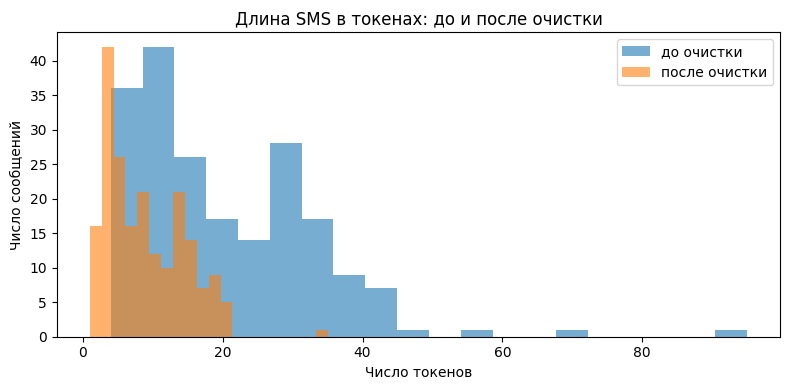

In [7]:
# Гистограммы длины до/после
fig, ax = plt.subplots()
ax.hist(subset["len_before"], bins=20, alpha=0.6, label="до очистки")
ax.hist(subset["len_after"], bins=20, alpha=0.6, label="после очистки")
ax.set_title("Длина SMS в токенах: до и после очистки")
ax.set_xlabel("Число токенов")
ax.set_ylabel("Число сообщений")
ax.legend()
plt.tight_layout()
plt.show()


### Вывод по пункту 3

1. На 200 SMS средняя длина упала с **~20.3** до **~8.9** токенов (примерно **-56%**).  
2. Словарь признаков становится меньше и чище — модели проще отделять spam от ham.  
3. Минус: можно потерять отдельные маркеры, но для этой задачи очистка в целом полезна.


## 4. Векторизация: CountVectorizer vs TF-IDF

- **CountVectorizer** — сколько раз слово встретилось в документе.  
- **TF-IDF** — усиливает слова, важные для документа, и ослабляет слова, которые есть почти везде.

**На нашем примере.**  
Берём корпус из 12 SMS и сравниваем оба вектора для одного и того же сообщения.


In [8]:
# Корпус 12 документов (смесь ham/spam)
corpus_df = pd.concat([
    df[df["label"] == "ham"].head(6),
    df[df["label"] == "spam"].head(6),
], ignore_index=True)

corpus = corpus_df["sms_message"].tolist()
print("Размер корпуса:", len(corpus))

# Мешок слов: простые счётчики
count_vec = CountVectorizer()
X_count = count_vec.fit_transform(corpus)

# TF-IDF: взвешенные частоты
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(corpus)

print("Число признаков (слов):", len(count_vec.get_feature_names_out()))


Размер корпуса: 12
Число признаков (слов): 180


In [ ]:
#Смотрим какие слова сколько раз встречаются в спамовых сообщениях и какие имеют наибольший TF-IDF вес

# Берём один и тот же документ (индекс 6) — spam-пример из корпуса
doc_id = 6

# Список всех слов-признаков из словаря CountVectorizer
words = count_vec.get_feature_names_out()

# Вектор Count для этого SMS: обычный плотный массив чисел
count_row = X_count[doc_id].toarray().ravel()

# Вектор TF-IDF для того же SMS (те же слова, другие веса)
tfidf_row = X_tfidf[doc_id].toarray().ravel()

# Индексы только тех слов, которые реально есть в этом SMS (count > 0)
# Остальные слова корпуса здесь нули — их сравнивать незачем
nonzero_idx = np.where(count_row > 0)[0]

# Таблица сравнения: слово | сколько раз встретилось | TF-IDF вес
compare = pd.DataFrame({
    "word": words[nonzero_idx],          # названия слов
    "count": count_row[nonzero_idx],     # частоты из CountVectorizer
    "tfidf": tfidf_row[nonzero_idx],     # веса из TF-IDF
}).sort_values("tfidf", ascending=False)  # сверху слова с наибольшим TF-IDF

print("Документ:")
print(corpus[doc_id])
print("\nКласс:", corpus_df.loc[doc_id, "label"])
display(compare.head(15))


Документ:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Класс: spam


,word,count,tfidf
7,entry,2,0.380155
8,fa,2,0.380155
19,to,3,0.250658
0,08452810075over18,1,0.190077
1,2005,1,0.190077
18,tkts,1,0.190077
17,text,1,0.190077
15,receive,1,0.190077
14,rate,1,0.190077
13,question,1,0.190077


### Вывод по пункту 4

1. **Count** показывает сырую частоту; **TF-IDF** перераспределяет веса.  
2. В TF-IDF больший вес получают слова, характерные для документа и редкие в корпусе (часто маркеры спама вроде `free`, `win`, `claim`).  
3. Для задачи spam/ham лучше **TF-IDF**: общие слова (`u`, `call`) приглушаются, отличительные усиливаются.


## 5. Обучение наивного Байеса

Наивный Байес оценивает: «насколько слова сообщения похожи на спам» и «насколько — на обычное».  
«Наивный» = считает слова условно независимыми. Это упрощение, но для текстов часто работает хорошо.

**На нашем примере.**  
Берём все SMS, превращаем текст в числа (TF-IDF), учим наивный Байес, смотрим качество и разбираем 5 примеров предсказаний.


In [ ]:
# Бинарная метка: spam=1, ham=0
y = (df["label"] == "spam").astype(int)
X_text = df["sms_message"]

# Train/test с сохранением доли классов
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Пайплайн: TF-IDF + Naive Bayes
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,          # нижний регистр
        stop_words="english",    # убрать английские стоп-слова
        ngram_range=(1, 2),      # слова и пары слов
        min_df=2,                # слово хотя бы в 2 документах
    )),
    ("nb", MultinomialNB()),
])

# Обучаем только на train
model.fit(X_train, y_train)

# Предсказания и вероятности на test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nclassification_report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=3))


Accuracy: 0.9706
Precision: 1.0
Recall: 0.7807
F1-score: 0.8769

classification_report:
              precision    recall  f1-score   support

         ham      0.967     1.000     0.983      1206
        spam      1.000     0.781     0.877       187

    accuracy                          0.971      1393
   macro avg      0.984     0.890     0.930      1393
weighted avg      0.972     0.971     0.969      1393




1. **Accuracy ≈ 0.97** — модель в целом часто права, но при дисбалансе это ещё не всё.  
2. По спаму **Precision = 1.0**: если модель сказала «spam», она почти не ошибается (ложных обвинений нет).  
3. **Recall ≈ 0.78**: около 22% спама всё же пропускает.  
4. **F1 ≈ 0.88** — хороший баланс для редкого класса `spam`.  
5. Для `ham` почти идеально (recall = 1.0): обычные сообщения модель почти не портит.


In [11]:
# 5 примеров из теста: текст, истина, прогноз, вероятности
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Возьмём 3 верных и по возможности ошибки / пограничные случаи
example_ids = [0, 1, 2, 3, 4]
# Добавим первую ошибку, если есть
errors = np.where(y_pred != y_test_reset.to_numpy())[0]
if len(errors) > 0:
    example_ids[-1] = int(errors[0])

examples = []
for i in example_ids:
    examples.append({
        "text": X_test_reset.iloc[i][:90] + ("..." if len(X_test_reset.iloc[i]) > 90 else ""),
        "true": "spam" if y_test_reset.iloc[i] == 1 else "ham",
        "pred": "spam" if y_pred[i] == 1 else "ham",
        "p_ham": round(float(y_proba[i, 0]), 3),
        "p_spam": round(float(y_proba[i, 1]), 3),
    })

examples_df = pd.DataFrame(examples)
display(examples_df)


,text,true,pred,p_ham,p_spam
0,Blank is Blank. But wat is blank? Lol,ham,ham,0.995,0.005
1,"Hi babe its Jordan, how r u? Im home from abro...",spam,ham,0.832,0.168
2,"How long has it been since you screamed, princ...",ham,ham,0.990,0.010
3,Lol no. Just trying to make your day a little ...,ham,ham,0.983,0.017
4,"Hi babe its Jordan, how r u? Im home from abro...",spam,ham,0.832,0.168


### Вывод по пункту 5

1. Качество высокое: accuracy ≈ **0.970**, precision по spam = **1.0**, recall ≈ **0.78**, F1 ≈ **0.88**.  
2. Модель **уверена** на шаблонном спаме. Ошибки чаще как **пропуск спама** (recall ниже precision), а не как ложные обвинения.  
3. Ограничение Naive Bayes: упрощённая независимость слов; тонкий смысл и маскировку спама под обычный разговор ловит хуже.


## 6. Итоговые выводы

1. **Предобработка** сильно укорачивает SMS (~в 2 раза) и убирает шум — признаки становятся стабильнее.  
2. **Count** считает частоты; **TF-IDF** усиливает характерные слова и лучше подходит для spam/ham.  
3. **Наивный Байес + TF-IDF** даёт accuracy ≈ 0.97 и F1 по spam ≈ 0.88: быстрый и сильный базовый вариант.  
4. **Ограничения:** дисбаланс классов, сленг/новые слова, слабый учёт сложного смысла.  
5. **Самое полезное:** полный пайплайн `анализ → токены/очистка → TF-IDF → MultinomialNB → разбор вероятностей`.
